In [1]:
## tools

from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper

/var/folders/_5/8v6z9x_52gs8j2rm4lkbr11h0000gn/T/ipykernel_14787/2294583264.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun


In [2]:
## get the top 2 results with max 500 character

api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv, description="Query arxiv papers")
print(arxiv.name)

arxiv


In [5]:
result = arxiv.invoke("Attention is all you need")
print(result)

Published: 2021-05-06
Title: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet
Authors: Luke Melas-Kyriazi
Summary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi


In [8]:
api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=2, doc_content_chars_max=500)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
print(wiki.name)

wikipedia


In [9]:
result = wiki.invoke("Attention is all you need")
print(result)

Page: Attention Is All You Need
Summary: "Attention Is All You Need" is a 2017 research paper in machine learning authored by eight scientists and engineers working at Google. The paper introduced a new deep learning architecture known as the transformer, based on the attention mechanism proposed in 2014 by Bahdanau et al. The transformer approach it describes has become the main architecture of a wide variety of artificial intelligence, including large language models. At the time, the focus of


In [10]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [12]:
## Tavily Search Tool
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

In [13]:
tavily.invoke("Provide me the recent AI News")

[{'title': 'Artificial Intelligence News -- ScienceDaily',
  'url': 'https://www.sciencedaily.com/news/computers_math/artificial_intelligence',
  'content': '### Tuesday, January 13, 2026\n\n### Sunday, November 16, 2025\n\n### Sunday, February 1, 2026\n\n### Wednesday, November 5, 2025\n\n### Tuesday, October 28, 2025\n\n### Wednesday, October 22, 2025\n\n### Monday, October 13, 2025\n\n### Thursday, October 9, 2025\n\n### Tuesday, October 14, 2025\n\n### Saturday, October 4, 2025\n\n### Sunday, September 28, 2025\n\n### Thursday, September 25, 2025\n\n### Wednesday, September 24, 2025\n\n### Friday, November 14, 2025\n\n### Sunday, September 7, 2025\n\n### Friday, August 22, 2025\n\n### Wednesday, August 27, 2025\n\n### Wednesday, August 13, 2025\n\n### Saturday, November 1, 2025\n\n### Friday, July 25, 2025\n\n### Thursday, July 24, 2025\n\n### Tuesday, July 8, 2025\n\n### Wednesday, July 2, 2025\n\n### Sunday, August 24, 2025\n\n### Wednesday, June 25, 2025\n\n### Sunday, June 22, 

In [14]:
## Combining all these tools in the list
tools=[arxiv, wiki, tavily]

In [15]:
## initialize the LLM Model
from langchain_groq import ChatGroq

llm = ChatGroq(model="llama-3.3-70b-versatile")

In [16]:
## bind tools with llm

llm_with_tools = llm.bind_tools(tools=tools)


In [17]:
## Execute the call
llm_with_tools.invoke("What is the recent news on AI?")

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'xn1btvs43', 'function': {'arguments': '{"query":"recent news on AI"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 461, 'total_tokens': 482, 'completion_time': 0.057159563, 'completion_tokens_details': None, 'prompt_time': 0.394564572, 'prompt_tokens_details': None, 'queue_time': 0.29246903, 'total_time': 0.451724135}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e6e3d-dfe1-7f33-b229-452e040557e8-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'recent news on AI'}, 'id': 'xn1btvs43', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 461, 'output_tokens': 21, 'total_tokens': 482})

In [18]:
## Workflow - Langgraph      
## State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage  ## Either a human or AI message
from typing import Annotated   ## labelling
from langgraph.graph.message import add_messages  ## Reducers in Langgraph

In [ ]:
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [20]:
## Entire Chatbot with Langgraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

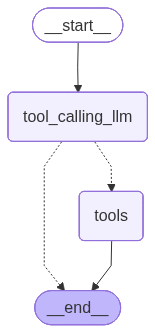

In [21]:
## Node definition
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

## Build Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools)) 

## Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))


In [23]:
messages=graph.invoke({"messages": "1706.03762"})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (a3zngvqpv)
 Call ID: a3zngvqpv
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, base


In [24]:
messages=graph.invoke({"messages": "Hi my name is Abhinav"})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hi my name is Abhinav
================================== Ai Message ==================================

It's nice to meet you, Abhinav. Is there something I can help you with or would you like to chat?


In [ ]:
## Node definition
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

## Build Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools)) 

## Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition,)
builder.add_edge("tools", "tool_calling_llm")

graph = builder.compile()


In [32]:
messages=graph.invoke({"messages": "What is the recent AI news and then please tell me the recent research paper on quantum computing"})
for m in messages['messages']:
    m.pretty_print()

HTTPError: Page request resulted in HTTP 429 (https://export.arxiv.org/api/query?search_query=recent+research+paper+on+quantum+computing&id_list=&sortBy=relevance&sortOrder=descending&start=0&max_results=100)